# Imports + Config

In [ ]:
# Install dependencies
!pip -q install requests beautifulsoup4 lxml tqdm pandas yfinance

# Imports
import os
import re
import json
import time
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta, timezone
from urllib.parse import urljoin, urlparse, urlunparse

import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import yfinance as yf

import matplotlib.pyplot as plt


# Config (paths + limits)
BASE_DIR = "."
COMPANIES_CSV = os.path.join(BASE_DIR, "companies.csv")

OUT_FDA_JSONL   = os.path.join(BASE_DIR, "data", "regulatory", "fda_docs.jsonl")
OUT_GDELT_JSONL = os.path.join(BASE_DIR, "data", "news", "gdelt_articles.jsonl")
OUT_YF_DIR      = os.path.join(BASE_DIR, "data", "financial", "yahoo")

OUT_GDELT_FAILURES_JSON = os.path.join(BASE_DIR, "data", "news", "gdelt_articles_failures.json")
OUT_NEWS_CLEAN_JSONL = os.path.join(BASE_DIR, "data", "news", "news_articles_clean.jsonl")
OUT_NEWS_DEDUP_JSONL = os.path.join(BASE_DIR, "data", "news", "news_articles_dedup.jsonl")
OUT_KG_EDGES_JSONL = os.path.join(BASE_DIR, "data", "kg", "kg_edges.jsonl")
OUT_KG_NODES_JSONL = os.path.join(BASE_DIR, "data", "kg", "kg_nodes.jsonl")
OUT_MASTER_JSONL = os.path.join(BASE_DIR, "data", "master", "master_records.jsonl")


os.makedirs(os.path.dirname(OUT_FDA_JSONL), exist_ok=True)
os.makedirs(os.path.dirname(OUT_GDELT_JSONL), exist_ok=True)
os.makedirs(OUT_YF_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data", "kg"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data", "master"), exist_ok=True)

# Run controls
FDA_MAX_PAGES = 200
FDA_MIN_RELEVANCE = 3
FDA_DELAY_S = 1.0

# GDELT CONFIG
GDELT_DAYS_BACK = 90 # 3 months
GDELT_DELAY_S = 30.0 # slower to reduce rate limit issues
GDELT_MAXRECORDS = 250
GDELT_RETRIES = 3
GDELT_RETRY_BASE_SLEEP = 45
GDELT_RETRIES = 5

YF_PERIOD = "5y"


# Load companies + build alias list

In [ ]:
companies_df = pd.read_csv(COMPANIES_CSV)

def build_aliases(df: pd.DataFrame) -> list[str]:
    aliases = []
    for _, row in df.iterrows():
        aliases.append(str(row.get("company_name","")).strip())
        aliases.append(str(row.get("ticker","")).strip())
        extra = str(row.get("aliases","")).strip()
        if extra:
            aliases.extend([a.strip() for a in extra.split(";") if a.strip()])
    seen, out = set(), []
    for a in aliases:
        if a and a not in seen:
            out.append(a)
            seen.add(a)
    return out

COMPANY_ALIASES = build_aliases(companies_df)
len(COMPANY_ALIASES), COMPANY_ALIASES[:10]


def build_gdelt_query(name, ticker=None, aliases=None):
    """
    Final stable GDELT query builder.
    Uses company name + alias only.
    Avoids tickers (main source of problems).
    """

    terms = []

    # Main company name
    if pd.notna(name) and str(name).strip():
        terms.append(f'"{str(name).strip()}"')

    # One alias max (avoid complex OR chains)
    if aliases is not None and pd.notna(aliases):
        alias_list = [a.strip() for a in str(aliases).split(";") if a.strip()]

        if alias_list:
            alias = alias_list[0]

            # Avoid too-short alias phrases
            if len(alias) >= 4:
                terms.append(f'"{alias}"')

    if not terms:
        raise ValueError("No valid GDELT search terms")

    if len(terms) == 1:
        entity_clause = terms[0]
    else:
        entity_clause = "(" + " OR ".join(terms) + ")"

    topic_clause = "(health OR FDA OR drug OR device OR recall OR approval)"

    return f"{entity_clause} AND {topic_clause}"


# Helper functions

In [ ]:
def now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def normalize_ws(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "")).strip()

def normalize_url(url: str) -> str:
    # Drop fragments, normalize trailing slashes, normalize netloc casing.
    p = urlparse(url)
    p = p._replace(fragment="", netloc=p.netloc.lower())
    path = p.path or "/"
    if path != "/" and path.endswith("/"):
        path = path[:-1]
    p = p._replace(path=path)
    return urlunparse(p)

def safe_makedirs_for_file(path: str):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)


# Crawler 1: FDA focused crawler (JSONL)

In [ ]:
FDA_ALLOWED_DOMAINS = {"www.fda.gov", "fda.gov"}

FDA_SEEDS = [
    "https://www.fda.gov/safety/recalls-market-withdrawals-safety-alerts",
    "https://www.fda.gov/drugs/drug-safety-and-availability",
    "https://www.fda.gov/news-events/fda-newsroom/press-announcements",]

FDA_KEYWORDS = [
    "recall", "warning letter", "safety", "adverse", "labeling", "approval", "enforcement",
    "market withdrawal", "alert", "communication", "inspection",]

def fda_is_allowed(url: str) -> bool:
    try:
        host = urlparse(url).netloc.lower()
        return host in FDA_ALLOWED_DOMAINS or host.endswith(".fda.gov")
    except Exception:
        return False

def fda_relevance_score(text: str, url: str = "") -> int:
    t = (text or "").lower()
    u = (url or "").lower()
    score = 0
    for kw in FDA_KEYWORDS:
        if kw in t:
            score += 2
        if kw.replace(" ", "-") in u or kw.replace(" ", "") in u:
            score += 1
    return score

def fda_extract_main_text(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")
    for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
        tag.decompose()
    main = soup.find("main") or soup.find("article")
    text = main.get_text(separator=" ", strip=True) if main else soup.get_text(separator=" ", strip=True)
    return normalize_ws(text)

def fda_extract_title(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")
    if soup.title and soup.title.text:
        return normalize_ws(soup.title.text)
    h1 = soup.find("h1")
    return normalize_ws(h1.get_text(strip=True)) if h1 else ""

def fda_extract_links(html: str, base_url: str) -> list[str]:
    soup = BeautifulSoup(html, "lxml")
    links = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if href.startswith("#") or href.lower().startswith("javascript:"):
            continue
        abs_url = normalize_url(urljoin(base_url, href))
        if fda_is_allowed(abs_url):
            links.append(abs_url)
    return links

def lightweight_mentions(text: str, company_aliases: list[str]) -> list[str]:
    t = text or ""
    hits = []
    for alias in company_aliases:
        a = alias.strip()
        if not a:
            continue
        if a.isupper() and 1 < len(a) <= 5:
            pattern = rf"\b{re.escape(a)}\b"
            if re.search(pattern, t):  # case-sensitive
                hits.append(a)
        else:
            pattern = rf"\b{re.escape(a)}\b"
            if re.search(pattern, t, flags=re.IGNORECASE):
                hits.append(a)

    # de-dupe preserving order
    seen, out = set(), []
    for h in hits:
        if h not in seen:
            out.append(h)
            seen.add(h)
    return out

def fda_fetch(session: requests.Session, url: str, timeout: int = 20) -> tuple[str|None, int|None, str]:
    headers = {
        "User-Agent": "MSDS459-KG-Crawler/1.0 (educational)",
        "Accept-Language": "en-US,en;q=0.9",
    }
    try:
        r = session.get(url, headers=headers, timeout=timeout)
        status = r.status_code
        final_url = normalize_url(r.url)
        if status != 200:
            return None, status, final_url
        ctype = (r.headers.get("Content-Type") or "").lower()
        if "text/html" not in ctype:
            return None, status, final_url
        return r.text, status, final_url
    except requests.RequestException:
        return None, None, normalize_url(url)

@dataclass
class FDADoc:
    source: str
    url: str
    fetched_at: str
    http_status: int|None
    title: str
    text: str
    relevance: int
    mentions: list[str]

def run_fda_crawler(
    out_jsonl: str,
    seeds: list[str] = FDA_SEEDS,
    max_pages: int = 200,
    min_relevance: int = 3,
    delay_s: float = 1.0,
    company_aliases: list[str] = None
) -> None:
    safe_makedirs_for_file(out_jsonl)
    company_aliases = company_aliases or []

    seen = set()
    frontier = [normalize_url(s) for s in seeds]
    frontier_set = set(frontier)

    wrote = 0

    with requests.Session() as session, open(out_jsonl, "w", encoding="utf-8") as f:
        for _ in tqdm(range(max_pages), desc="FDA Crawl"):
            if not frontier:
                break

            frontier.sort(key=lambda u: fda_relevance_score("", u), reverse=True)
            url = frontier.pop(0)
            frontier_set.discard(url)

            if url in seen:
                continue
            seen.add(url)

            html, status, final_url = fda_fetch(session, url)
            time.sleep(delay_s)

            if not html:
                continue

            title = fda_extract_title(html)
            text = fda_extract_main_text(html)
            rel = fda_relevance_score(text, final_url)

            if rel >= min_relevance and len(text) > 400:
                mentions = lightweight_mentions(text, company_aliases)
                rec = FDADoc(
                    source="FDA",
                    url=final_url,
                    fetched_at=now_iso(),
                    http_status=status,
                    title=title,
                    text=text,
                    relevance=rel,
                    mentions=mentions,
                )
                f.write(json.dumps(asdict(rec), ensure_ascii=False) + "\n")
                wrote += 1

            for link in fda_extract_links(html, final_url):
                if link not in seen and link not in frontier_set and len(frontier) < max_pages * 10:
                    frontier.append(link)
                    frontier_set.add(link)

    print(f"FDA done. Wrote {wrote} docs to {out_jsonl}. Visited {len(seen)} pages.")


# Crawler 2: GDELT collector (JSONL)

In [ ]:
def gdelt_fetch(query, start_dt, end_dt, maxrecords=25, retries=3, base_sleep=15):
    """
    Fetch GDELT DOC API results safely.
    Handles:
    - empty responses
    - HTML/text error pages
    - JSON decode failures
    - 429 Too Many Requests
    """
    url = "https://api.gdeltproject.org/api/v2/doc/doc"

    params = {
        "query": query,
        "mode": "ArtList",
        "format": "json",
        "maxrecords": int(maxrecords),
        "startdatetime": start_dt.strftime("%Y%m%d%H%M%S"),
        "enddatetime": end_dt.strftime("%Y%m%d%H%M%S"),
        "sort": "DateDesc",
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; FDA-Crawler/1.0)"
    }

    last_error = None

    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=30)

            content_type = (r.headers.get("Content-Type") or "").lower()
            text = (r.text or "").strip()

            print(f"[GDELT] attempt={attempt} status={r.status_code} content_type={content_type}")

            if r.status_code == 429:
                raise requests.HTTPError(f"429 Too Many Requests for url: {r.url}")

            r.raise_for_status()

            if not text:
                raise ValueError("Empty response body from GDELT")

            # If GDELT sends back HTML or plain text error instead of JSON
            if ("text/html" in content_type or "text/plain" in content_type) and not text.startswith("{"):
                preview = text[:500]
                raise ValueError(f"Non-JSON response from GDELT. First 500 chars:\n{preview}")

            try:
                data = r.json()
            except Exception:
                preview = text[:500]
                raise ValueError(f"JSON parse failed. First 500 chars:\n{preview}")

            if not isinstance(data, dict):
                raise ValueError("Unexpected GDELT JSON structure")

            return data

        except Exception as e:
            last_error = e
            print(f"[GDELT] attempt {attempt} failed: {e}")

            if attempt < retries:
                sleep_for = base_sleep * attempt
                print(f"[GDELT] sleeping {sleep_for}s before retry")
                time.sleep(sleep_for)

    raise RuntimeError(f"GDELT request failed after {retries} attempts: {last_error}")


def run_gdelt_collector(
    companies_df: pd.DataFrame,
    out_jsonl: str,
    days_back: int = 14,
    delay_s: float = 12.0,
    maxrecords: int = 25
):
    safe_makedirs_for_file(out_jsonl)

    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(days=days_back)

    wrote = 0
    failures = []

    with open(out_jsonl, "w", encoding="utf-8") as f:
        for _, row in tqdm(companies_df.iterrows(), total=len(companies_df), desc="GDELT"):
            name = str(row.get("company_name", "")).strip()
            ticker = str(row.get("ticker", "")).strip()
            aliases = row.get("aliases", "")

            try:
                q = build_gdelt_query(name=name, ticker=ticker, aliases=aliases)

                data = gdelt_fetch(
                    query=q,
                    start_dt=start_dt,
                    end_dt=end_dt,
                    maxrecords=maxrecords,
                    retries=GDELT_RETRIES,
                    base_sleep=GDELT_RETRY_BASE_SLEEP
                )

                articles = data.get("articles", [])
                print(f"[GDELT] {name} ({ticker}) -> {len(articles)} articles")

                for a in articles:
                    rec = {
                        "source": "GDELT",
                        "company": name,
                        "ticker": ticker,
                        "query": q,
                        "fetched_at": now_iso(),
                        "url": a.get("url"),
                        "title": a.get("title"),
                        "seendate": a.get("seendate"),
                        "domain": a.get("domain"),
                        "language": a.get("language"),
                        "sourcecountry": a.get("sourcecountry") or a.get("sourceCountry"),
                        "tone": a.get("tone"),
                    }
                    f.write(json.dumps(rec, ensure_ascii=False) + "\n")
                    wrote += 1

            except Exception as e:
                print(f"[GDELT] Failed for {name} ({ticker}): {e}")
                failures.append({
                    "company": name,
                    "ticker": ticker,
                    "error": str(e)
                })

            time.sleep(delay_s)

    print(f"GDELT done. Wrote {wrote} records to {out_jsonl}.")
    print(f"GDELT failures: {len(failures)}")

    if failures:
        fail_path = out_jsonl.replace(".jsonl", "_failures.json")
        with open(fail_path, "w", encoding="utf-8") as ff:
            json.dump(failures, ff, ensure_ascii=False, indent=2)
        print(f"Saved failures to {fail_path}")


In [ ]:
# Test

# Quick single-company test
test_name = companies_df.iloc[0]["company_name"]
test_ticker = companies_df.iloc[0]["ticker"]
test_aliases = companies_df.iloc[0]["aliases"] if "aliases" in companies_df.columns else ""

test_end_dt = datetime.now(timezone.utc)
test_start_dt = test_end_dt - timedelta(days=GDELT_DAYS_BACK)

test_query = build_gdelt_query(
    name=test_name,
    ticker=test_ticker,
    aliases=test_aliases
)

print("TEST QUERY:", test_query)

test_data = gdelt_fetch(
    query=test_query,
    start_dt=test_start_dt,
    end_dt=test_end_dt,
    maxrecords=10,
    retries=GDELT_RETRIES,
    base_sleep=GDELT_RETRY_BASE_SLEEP
)

print("Returned keys:", test_data.keys())
print("Article count:", len(test_data.get("articles", [])))

TEST QUERY: ("Pfizer Inc." OR "Pfizer") AND (health OR FDA OR drug OR device OR recall OR approval)
[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=10&startdatetime=20251216072839&enddatetime=20260316072839&sort=DateDesc
[GDELT] sleeping 45s before retry
[GDELT] attempt=2 status=429 content_type=
[GDELT] attempt 2 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=10&startdatetime=20251216072839&enddatetime=20260316072839&sort=DateDesc
[GDELT] sleeping 90s before retry
[GDELT] attempt=3 status=200 content_type=application/json; charset=utf-8
Returned keys: dict_keys(['artic

# Crawler 3: Yahoo Finance time series (CSV)

In [ ]:
def run_yahoo_finance_downloader(
    companies_df: pd.DataFrame,
    out_dir: str,
    period: str = "5y"
) -> pd.DataFrame:
    os.makedirs(out_dir, exist_ok=True)

    summary = []
    for tkr in tqdm(companies_df["ticker"].tolist(), desc="Yahoo Finance"):
        df = yf.download(tkr, period=period, interval="1d", progress=False)
        df = df.reset_index()

        out_path = os.path.join(out_dir, f"{tkr}.csv")
        df.to_csv(out_path, index=False)

        summary.append({
            "ticker": tkr,
            "rows": len(df),
            "start": str(df["Date"].min()) if len(df) else None,
            "end": str(df["Date"].max()) if len(df) else None
        })

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
    print(f"Yahoo Finance done. Saved CSVs to {out_dir}")
    return summary_df


# Run Crawlers

In [ ]:
# FDA
run_fda_crawler(
    out_jsonl=OUT_FDA_JSONL,
    max_pages=FDA_MAX_PAGES,
    min_relevance=FDA_MIN_RELEVANCE,
    delay_s=FDA_DELAY_S,
    company_aliases=COMPANY_ALIASES)


# Yahoo Finance
yf_summary = run_yahoo_finance_downloader(
    companies_df=companies_df,
    out_dir=OUT_YF_DIR,
    period=YF_PERIOD)
yf_summary.head()


# GDELT
run_gdelt_collector(
    companies_df=companies_df,
    out_jsonl=OUT_GDELT_JSONL,
    days_back=GDELT_DAYS_BACK,
    delay_s=GDELT_DELAY_S,
    maxrecords=GDELT_MAXRECORDS)


FDA Crawl: 100%|██████████████████████████████| 200/200 [07:04<00:00,  2.12s/it]


FDA done. Wrote 195 docs to ./data/regulatory/fda_docs.jsonl. Visited 200 pages.


Yahoo Finance: 100%|████████████████████████████| 18/18 [00:27<00:00,  1.50s/it]


Yahoo Finance done. Saved CSVs to ./data/financial/yahoo


GDELT:   0%|                                             | 0/18 [00:00<?, ?it/s]

...

[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%22CVS+Health+Corporation%22+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=250&startdatetime=20251216073838&enddatetime=20260316073838&sort=DateDesc
[GDELT] sleeping 45s before retry
[GDELT] attempt=2 status=200 content_type=application/json; charset=utf-8
[GDELT] CVS Health Corporation (CVS) -> 48 articles


GDELT:  94%|█████████████████████████████████  | 17/18 [39:49<01:57, 117.69s/it]

[GDELT] attempt=1 status=200 content_type=application/json; charset=utf-8
[GDELT] The Cigna Group (CI) -> 250 articles


GDELT: 100%|███████████████████████████████████| 18/18 [40:28<00:00, 134.94s/it]

GDELT done. Wrote 3514 records to ./data/news/gdelt_articles.jsonl.
GDELT failures: 2
Saved failures to ./data/news/gdelt_articles_failures.json


In [ ]:
# Retry failed companies only
failed_tickers = ["PFE", "ABBV", "BMY", "AMGN", "VRTX", "SYK", "CVS"]
retry_df = companies_df[companies_df["ticker"].isin(failed_tickers)]

run_gdelt_collector(
    companies_df=retry_df,
    out_jsonl=OUT_GDELT_JSONL.replace(".jsonl", "_retry.jsonl"),
    days_back=GDELT_DAYS_BACK,
    delay_s=45.0,          # extra cautious
    maxrecords=GDELT_MAXRECORDS
)

GDELT:   0%|                                              | 0/7 [00:00<?, ?it/s]

[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=250&startdatetime=20251216081907&enddatetime=20260316081907&sort=DateDesc
[GDELT] sleeping 45s before retry
[GDELT] attempt=2 status=429 content_type=
[GDELT] attempt 2 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=250&startdatetime=20251216081907&enddatetime=20260316081907&sort=DateDesc
[GDELT] sleeping 90s before retry
[GDELT] attempt=3 status=200 content_type=application/json; charset=utf-8
[GDELT] Pfizer Inc. (PFE) -> 250 articles


GDELT:  14%|█████▎                               | 1/7 [03:07<18:47, 187.90s/it]

[GDELT] attempt=1 status=200 content_type=application/json; charset=utf-8
[GDELT] AbbVie Inc. (ABBV) -> 250 articles


GDELT:  29%|██████████▌                          | 2/7 [04:01<09:03, 108.67s/it]

...

[GDELT] attempt=1 status=200 content_type=application/json; charset=utf-8
[GDELT] Stryker Corporation (SYK) -> 250 articles


GDELT:  86%|████████████████████████████████▌     | 6/7 [08:09<01:09, 69.25s/it]

[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%22CVS+Health+Corporation%22+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=250&startdatetime=20251216081907&enddatetime=20260316081907&sort=DateDesc
[GDELT] sleeping 45s before retry
[GDELT] attempt=2 status=200 content_type=application/json; charset=utf-8
[GDELT] CVS Health Corporation (CVS) -> 48 articles


GDELT: 100%|██████████████████████████████████████| 7/7 [09:44<00:00, 83.49s/it]

GDELT done. Wrote 1355 records to ./data/news/gdelt_articles_retry.jsonl.
GDELT failures: 0


In [ ]:
# Merge original + retry into one deduplicated file
import pandas as pd, json

dfs = []
for path in [OUT_GDELT_JSONL, OUT_GDELT_JSONL.replace(".jsonl","_retry.jsonl")]:
    rows = []
    try:
        with open(path) as f:
            for line in f:
                rows.append(json.loads(line))
        dfs.append(pd.DataFrame(rows))
    except FileNotFoundError:
        pass

merged = pd.concat(dfs).drop_duplicates(subset=["url"]).reset_index(drop=True)
with open(OUT_GDELT_JSONL.replace(".jsonl","_full.jsonl"), "w") as f:
    for _, row in merged.iterrows():
        f.write(json.dumps(row.to_dict()) + "\n")
print(f"Merged: {len(merged)} unique articles")

Merged: 3207 unique articles


# Data Check (FDA)

In [ ]:
def read_jsonl(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

fda_df = read_jsonl(OUT_FDA_JSONL)
fda_df[["title","url","relevance","mentions"]].head(10)


,title,url,relevance,mentions
0,"Recalls, Market Withdrawals, & Safety Alerts |...",https://www.fda.gov/safety/recalls-market-with...,12,[]
1,Enforcement Reports | FDA,https://www.fda.gov/safety/recalls-market-with...,15,[]
2,Recall Resources | FDA,https://www.fda.gov/safety/recalls-market-with...,12,[]
3,Industry Guidance For Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,10,[]
4,Major Product Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,8,[]
5,Additional Information about Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,14,[]
6,"Pure Vitamins and Natural Supplements, LLC Iss...",https://www.fda.gov/safety/recalls-market-with...,10,[]
7,Insulet Initiates Voluntary Medical Device Cor...,https://www.fda.gov/safety/recalls-market-with...,10,[]
8,Lidl US Issues Allergy Alert on Undeclared Haz...,https://www.fda.gov/safety/recalls-market-with...,8,[]
9,Primal Herbs Issues Voluntary Nationwide Recal...,https://www.fda.gov/safety/recalls-market-with...,10,[]


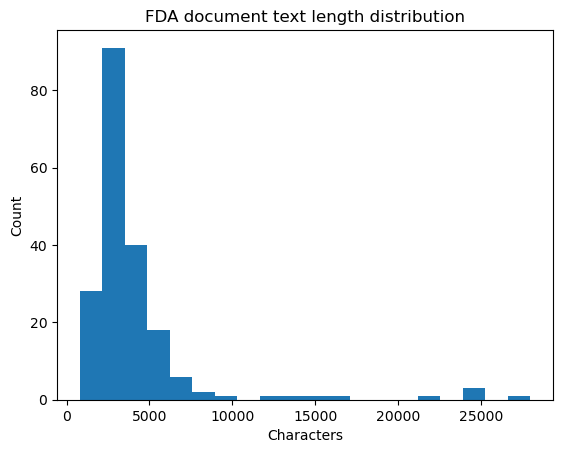

In [ ]:
fda_df["text_len"] = fda_df["text"].astype(str).str.len()

plt.figure()
plt.hist(fda_df["text_len"], bins=20)
plt.title("FDA document text length distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [ ]:
# Post-process: re-run mention matching on existing FDA docs
import re, json, pandas as pd
from collections import defaultdict

companies_df = pd.read_csv(COMPANIES_CSV)

# Build a ticker → aliases mapping
ticker_aliases = {}
for _, row in companies_df.iterrows():
    ticker = row["ticker"]
    names = [row["company_name"], ticker]
    if pd.notna(row.get("aliases", "")):
        names += [a.strip() for a in str(row["aliases"]).split(";")]
    ticker_aliases[ticker] = [n for n in names if n and len(str(n)) > 2]

def match_tickers(text):
    matched = []
    for ticker, aliases in ticker_aliases.items():
        for alias in aliases:
            pattern = rf"\b{re.escape(alias)}\b"
            flags = 0 if (alias.isupper() and len(alias) <= 5) else re.IGNORECASE
            if re.search(pattern, text, flags=flags):
                matched.append(ticker)
                break
    return list(set(matched))

# Re-process the FDA JSONL
updated = []
with open(OUT_FDA_JSONL) as f:
    for line in f:
        doc = json.loads(line)
        doc["tickers"] = match_tickers(doc.get("text", ""))
        updated.append(doc)

# Save enriched version
enriched_path = OUT_FDA_JSONL.replace(".jsonl", "_enriched.jsonl")
with open(enriched_path, "w") as f:
    for doc in updated:
        f.write(json.dumps(doc) + "\n")

# Summary
from collections import Counter
all_tickers = [t for doc in updated for t in doc["tickers"]]
print(Counter(all_tickers).most_common(10))
print(f"Docs with at least one match: {sum(1 for d in updated if d['tickers'])}/{len(updated)}")

[('BMY', 9), ('MDT', 3), ('CVS', 2), ('JNJ', 2), ('BSX', 2), ('MRK', 1)]
Docs with at least one match: 13/195


In [ ]:
# Post-process: re-run mention matching on existing FDA docs
import re, json, pandas as pd
from collections import defaultdict

companies_df = pd.read_csv(COMPANIES_CSV)

# Build a ticker → aliases mapping
ticker_aliases = {}
for _, row in companies_df.iterrows():
    ticker = row["ticker"]
    names = [row["company_name"], ticker]
    if pd.notna(row.get("aliases", "")):
        names += [a.strip() for a in str(row["aliases"]).split(";")]
    ticker_aliases[ticker] = [n for n in names if n and len(str(n)) > 2]

def match_tickers(text):
    matched = []
    for ticker, aliases in ticker_aliases.items():
        for alias in aliases:
            pattern = rf"\b{re.escape(alias)}\b"
            flags = 0 if (alias.isupper() and len(alias) <= 5) else re.IGNORECASE
            if re.search(pattern, text, flags=flags):
                matched.append(ticker)
                break
    return list(set(matched))

# Re-process the FDA JSONL
updated = []
with open(OUT_FDA_JSONL) as f:
    for line in f:
        doc = json.loads(line)
        doc["tickers"] = match_tickers(doc.get("text", ""))
        updated.append(doc)

# Save enriched version
enriched_path = OUT_FDA_JSONL.replace(".jsonl", "_enriched.jsonl")
with open(enriched_path, "w") as f:
    for doc in updated:
        f.write(json.dumps(doc) + "\n")

# Summary
from collections import Counter
all_tickers = [t for doc in updated for t in doc["tickers"]]
print(Counter(all_tickers).most_common(10))
print(f"Docs with at least one match: {sum(1 for d in updated if d['tickers'])}/{len(updated)}")

[('BMY', 9), ('MDT', 3), ('CVS', 2), ('JNJ', 2), ('BSX', 2), ('MRK', 1)]
Docs with at least one match: 13/195


In [ ]:
from collections import Counter

all_mentions = []
for m in fda_df["mentions"].dropna():
    all_mentions.extend(m)

counts = Counter(all_mentions)
top = counts.most_common(15)

top_df = pd.DataFrame(top, columns=["mention","count"])
top_df


,mention,count
0,BMS,9
1,J&J,2
2,Medtronic,2
3,Boston Scientific Corporation,2
4,Boston Scientific,2
5,CVS,2
6,Merck,1
7,Merck & Co,1
8,MDT,1


# Data Check (Yahoo Finance)

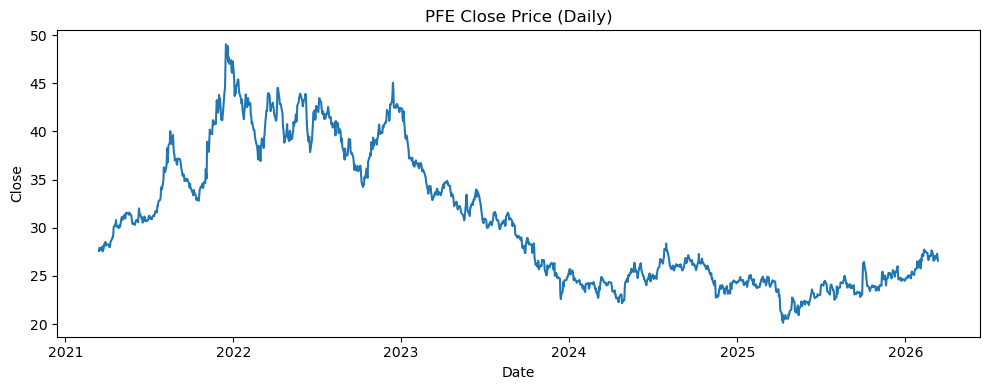

In [ ]:
ticker = "PFE"
pfe_path = os.path.join(OUT_YF_DIR, f"{ticker}.csv")
pfe = pd.read_csv(pfe_path)

pfe["Date"] = pd.to_datetime(pfe["Date"], errors="coerce")
pfe["Close"] = pd.to_numeric(pfe["Close"], errors="coerce")

pfe = pfe.dropna(subset=["Date", "Close"]).sort_values("Date")

plt.figure(figsize=(10,4))
plt.plot(pfe["Date"], pfe["Close"])
plt.title(f"{ticker} Close Price (Daily)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.tight_layout()
plt.show()


# Data Check (GDELT)

In [ ]:
import pandas as pd
import json

GDELT_FILE = "./data/news/gdelt_articles.jsonl"

records = []
with open(GDELT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

gdelt_df = pd.DataFrame(records)

print(gdelt_df.shape)
gdelt_df.head()

(3514, 12)


,source,company,ticker,query,fetched_at,url,title,seendate,domain,language,sourcecountry,tone
0,GDELT,Pfizer Inc.,PFE,"(""Pfizer Inc."" OR ""Pfizer"") AND (health OR FDA...",2026-03-16T07:38:46.391752+00:00,https://www.koreaherald.com/article/10695295,Aggressive outreach drives Chinese biotech suc...,20260316T070000Z,koreaherald.com,English,South Korea,None
1,GDELT,Pfizer Inc.,PFE,"(""Pfizer Inc."" OR ""Pfizer"") AND (health OR FDA...",2026-03-16T07:38:46.391979+00:00,https://www.themarketsdaily.com/2026/03/16/mov...,Movano Inc . ( NASDAQ : MOVE ) Short Interest ...,20260316T041500Z,themarketsdaily.com,English,United States,None
2,GDELT,Pfizer Inc.,PFE,"(""Pfizer Inc."" OR ""Pfizer"") AND (health OR FDA...",2026-03-16T07:38:46.392024+00:00,https://www.insidermonkey.com/blog/is-zoetis-i...,Is Zoetis Inc . ( ZTS ) A Good Stock To Buy No...,20260316T040000Z,insidermonkey.com,English,United States,None
3,GDELT,Pfizer Inc.,PFE,"(""Pfizer Inc."" OR ""Pfizer"") AND (health OR FDA...",2026-03-16T07:38:46.392045+00:00,https://www.insidermonkey.com/blog/is-pfizer-i...,Is Pfizer Inc . ( PFE ) One of Goldman Sachs T...,20260316T004500Z,insidermonkey.com,English,United States,None
4,GDELT,Pfizer Inc.,PFE,"(""Pfizer Inc."" OR ""Pfizer"") AND (health OR FDA...",2026-03-16T07:38:46.392062+00:00,https://finance.yahoo.com/news/pfizer-inc-pfe-...,Is Pfizer Inc . ( PFE ) One of Goldman Sachs T...,20260315T221500Z,finance.yahoo.com,English,United States,None


In [ ]:
# Clean up
gdelt_df["seendate"] = pd.to_datetime(gdelt_df["seendate"], errors="coerce")
gdelt_df["date"] = gdelt_df["seendate"].dt.date
gdelt_df["tone"] = pd.to_numeric(gdelt_df["tone"], errors="coerce")

gdelt_df[["company", "title", "domain", "seendate", "tone"]].head()

,company,title,domain,seendate,tone
0,Pfizer Inc.,Aggressive outreach drives Chinese biotech suc...,koreaherald.com,2026-03-16 07:00:00+00:00,NaN
1,Pfizer Inc.,Movano Inc . ( NASDAQ : MOVE ) Short Interest ...,themarketsdaily.com,2026-03-16 04:15:00+00:00,NaN
2,Pfizer Inc.,Is Zoetis Inc . ( ZTS ) A Good Stock To Buy No...,insidermonkey.com,2026-03-16 04:00:00+00:00,NaN
3,Pfizer Inc.,Is Pfizer Inc . ( PFE ) One of Goldman Sachs T...,insidermonkey.com,2026-03-16 00:45:00+00:00,NaN
4,Pfizer Inc.,Is Pfizer Inc . ( PFE ) One of Goldman Sachs T...,finance.yahoo.com,2026-03-15 22:15:00+00:00,NaN


# Articles per company

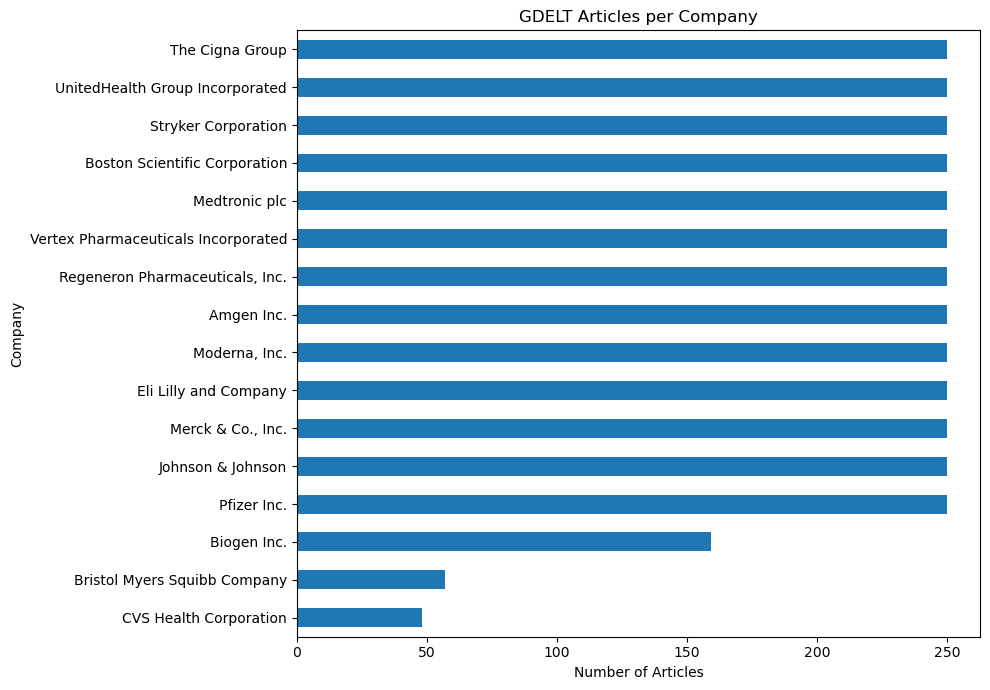

In [ ]:
import matplotlib.pyplot as plt

company_counts = (
    gdelt_df["company"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
company_counts.plot(kind="barh")
plt.title("GDELT Articles per Company")
plt.xlabel("Number of Articles")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

# Top news domains

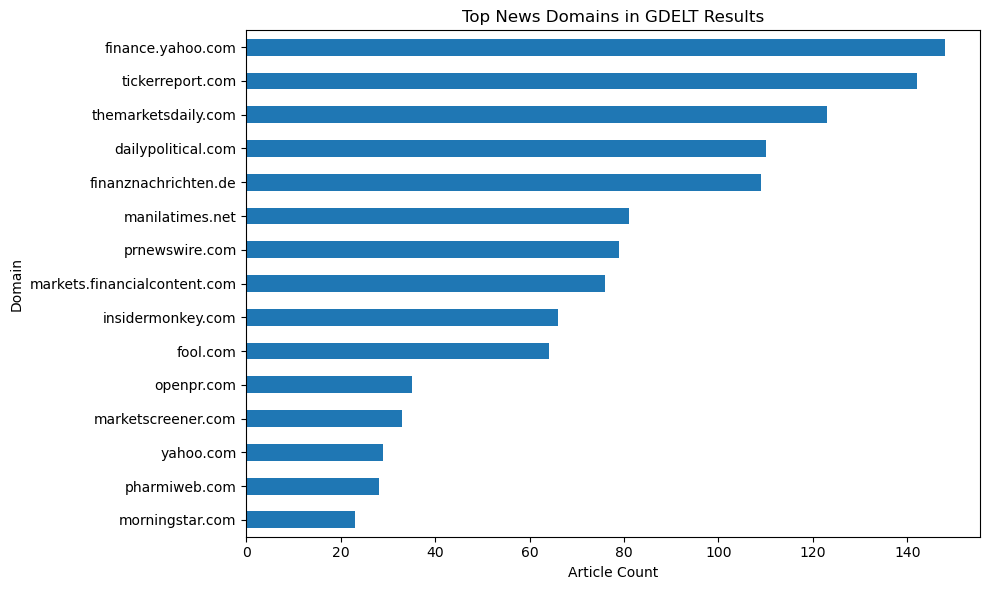

In [ ]:
top_domains = (
    gdelt_df["domain"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
top_domains.plot(kind="barh")
plt.title("Top News Domains in GDELT Results")
plt.xlabel("Article Count")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()

# Articles over time

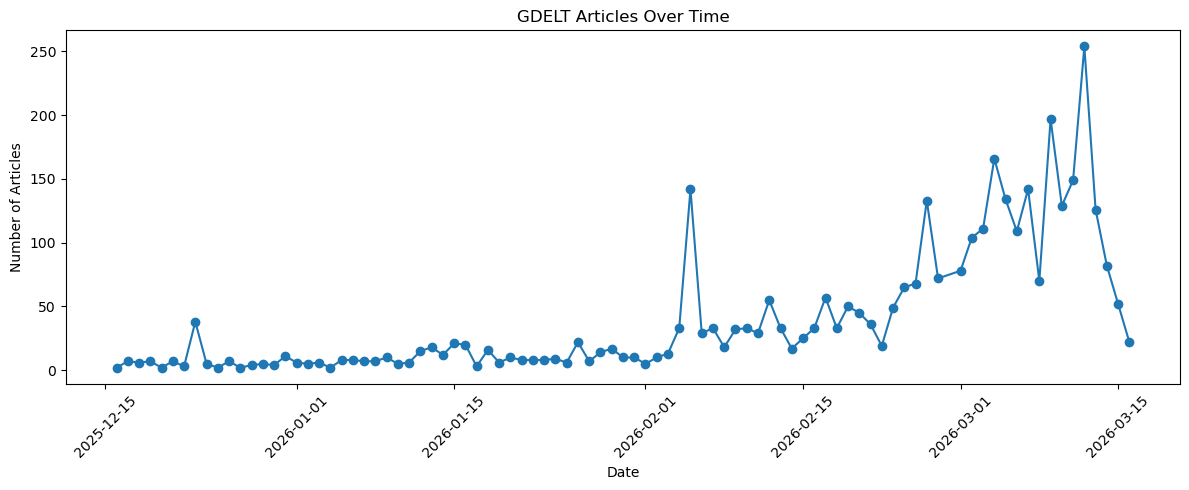

In [ ]:
daily_counts = (
    gdelt_df.groupby("date")
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(daily_counts.index, daily_counts.values, marker="o")
plt.title("GDELT Articles Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()